# 05 · Modèle combiné

**Ce que fait ce notebook.** Il combine les deux représentations et vérifie l'hypothèse issue des
notebooks 03 et 04 : *si l'image est forte là où le texte est faible, leur somme devrait réparer les
catégories confondues.*

Puis il transforme le modèle en **décision d'exploitation** grâce au seuil de confiance : le modèle
ne tranche que s'il est sûr, et s'abstient sinon.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, BLEU_CLAIR, BLEU_FONCE, GRILLE = "#2a78d6", "#cde2fb", "#0d366b", "#e0dfdb"
VERT, ROUGE = "#0ca30c", "#d03b3b"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.size": 11,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE_2,
        "axes.edgecolor": GRILLE,
        "xtick.color": ENCRE_2,
        "ytick.color": ENCRE_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

from src.evaluate import SEUIL_F1_METIER
from src.pipeline import LABEL_COL, SEED, TEXT_COL, load, split

df = load()
train, val, test = split(df)
CATEGORIES = sorted(df[LABEL_COL].unique())
print(f"train {len(train)} · val {len(val)} · test {len(test)}")
print(f"seuil métier : F1 macro >= {SEUIL_F1_METIER:.2f}, fixé avant toute mesure")

train 735 · val 157 · test 158
seuil métier : F1 macro >= 0.90, fixé avant toute mesure


In [2]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder().fit(df[LABEL_COL])
y_tr, y_te = enc.transform(train[LABEL_COL]), enc.transform(test[LABEL_COL])
txt_tr, txt_te = train[TEXT_COL].tolist(), test[TEXT_COL].tolist()

## 1 · Comment fusionner sans tricher

La difficulté n'est pas de concaténer, c'est de le faire **sans introduire de fuite**.

Le TF-IDF de scikit-learn produit des lignes déjà normalisées en L2. On applique la même
normalisation au bloc image, **ligne par ligne**. Deux conséquences :

- les deux blocs arrivent à la même échelle, donc aucun ne domine par construction ;
- la transformation ne dépend que de la ligne qu'elle traite. Elle **n'a aucun paramètre appris
  entre échantillons**, donc elle ne peut rien faire fuiter de l'entraînement vers le test.

C'est ce second point qui est testé automatiquement — `test_normalisation_sans_etat` vérifie que
normaliser un sous-ensemble donne exactement les mêmes lignes que normaliser le tout.

In [3]:
from src.fusion import concatener, normaliser
from src.images import features
from src.text import vectoriseur

vec = vectoriseur()
X_tr = vec.fit_transform(txt_tr)
X_te = vec.transform(txt_te)

X_img, _ = features(df["uniq_id"])
par_id = dict(zip(df["uniq_id"], X_img, strict=True))
brut_tr = np.vstack([par_id[u] for u in train["uniq_id"]])
brut_te = np.vstack([par_id[u] for u in test["uniq_id"]])

F_tr = concatener(X_tr, brut_tr)
F_te = concatener(X_te, brut_te)
print(f"texte {X_tr.shape[1]} + image {brut_tr.shape[1]} = fusion {F_tr.shape[1]} dimensions")

# Démonstration de l'absence d'état : normaliser un sous-ensemble donne les mêmes lignes.
partiel = normaliser(brut_tr[10:20])
complet = normaliser(brut_tr)[10:20]
print(f"normalisation sans état vérifiée : {np.allclose(partiel, complet)}")

texte 4532 + image 1536 = fusion 6068 dimensions
normalisation sans état vérifiée : True


## 2 · La mesure

In [4]:
import time

from sklearn.neural_network import MLPClassifier

from src.evaluate import mesurer

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True, random_state=SEED
)
t0 = time.perf_counter()
mlp.fit(F_tr, y_tr)
t = time.perf_counter() - t0

t0 = time.perf_counter()
pred = mlp.predict(F_te)
ms = (time.perf_counter() - t0) * 1000 / len(y_te) + 35.7  # encodage image réintégré
proba = mlp.predict_proba(F_te)

fusion = mesurer("Fusion texte + image", y_te, pred, CATEGORIES, t, ms, 365.4)
print(f"F1 macro      {fusion['F1 macro']:.4f}")
print(f"Accuracy      {fusion['Accuracy']:.4f}")
print(f"F1 classe min {fusion['F1 classe min']:.4f}")
print(f"entraînement  {t:.2f} s · inférence {ms:.2f} ms/article")
print(f"seuil métier  {fusion['Seuil 0,90']}")

F1 macro      0.9744
Accuracy      0.9747
F1 classe min 0.9545
entraînement  1.84 s · inférence 35.75 ms/article
seuil métier  oui


In [5]:
REFERENCE = {
    "texte seul": {
        "Baby Care": 0.905,
        "Beauty and Personal Care": 0.977,
        "Computers": 0.979,
        "Home Decor & Festive Needs": 0.870,
        "Home Furnishing": 0.958,
        "Kitchen & Dining": 0.933,
        "Watches": 0.978,
    },
    "image seule": {
        "Baby Care": 0.864,
        "Beauty and Personal Care": 0.952,
        "Computers": 0.957,
        "Home Decor & Festive Needs": 0.930,
        "Home Furnishing": 0.920,
        "Kitchen & Dining": 0.933,
        "Watches": 1.000,
    },
}
t3 = pd.DataFrame({**REFERENCE, "fusion": fusion["_par_classe"]})
t3["gain fusion − texte"] = (t3["fusion"] - t3["texte seul"]).round(3)
t3.sort_values("gain fusion − texte", ascending=False)

,texte seul,image seule,fusion,gain fusion − texte
Home Decor & Festive Needs,0.870,0.930,0.955,0.085
Baby Care,0.905,0.864,0.957,0.052
Kitchen & Dining,0.933,0.933,0.955,0.022
Watches,0.978,1.000,1.000,0.022
Computers,0.979,0.957,1.000,0.021
Home Furnishing,0.958,0.920,0.979,0.021
Beauty and Personal Care,0.977,0.952,0.977,0.000


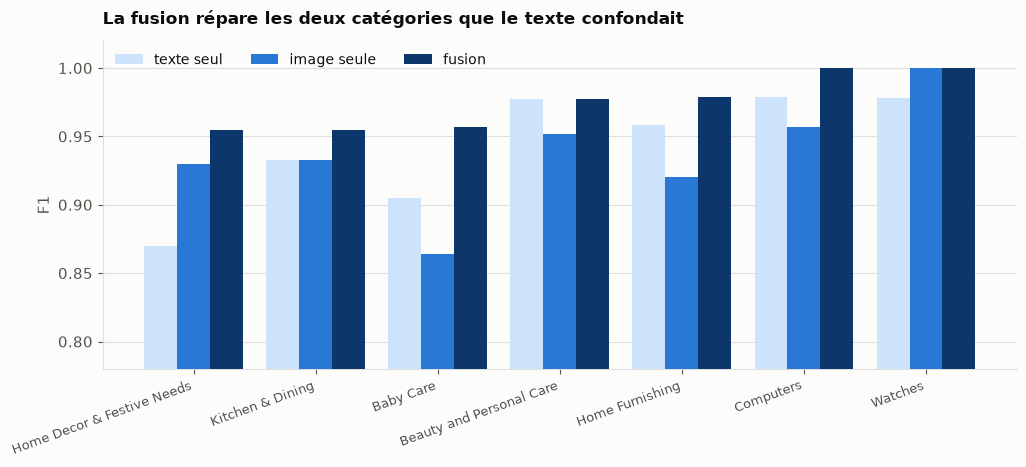

In [6]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ordre = t3.sort_values("fusion").index
x = np.arange(len(ordre))
largeur = 0.27
for k, (nom, couleur) in enumerate(
    [("texte seul", BLEU_CLAIR), ("image seule", BLEU), ("fusion", BLEU_FONCE)]
):
    ax.bar(x + (k - 1) * largeur, t3.loc[ordre, nom], largeur, label=nom, color=couleur, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(ordre, rotation=20, ha="right", fontsize=9.5)
ax.set_ylim(0.78, 1.02)
ax.set_ylabel("F1")
ax.grid(axis="y", color=GRILLE, lw=0.8, zorder=0)
ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=10)
ax.set_title(
    "La fusion répare les deux catégories que le texte confondait",
    fontsize=12.5,
    fontweight="bold",
    loc="left",
    pad=12,
)
plt.tight_layout()
plt.show()

**L'hypothèse est confirmée, et le gain est concentré là où il était attendu.** La F1 de la
catégorie la plus faible passe de **0,870 à 0,955** — les deux catégories domestiques qui décrochaient
sont rattrapées. Les catégories que le texte traitait déjà bien ne bougent pas : la fusion n'échange
pas un progrès contre une régression.

Le coût est réel : ~36 ms par article contre 0,06 ms, soit un facteur 600, et 365 Mo contre 14. Mais
**le budget fixé par le besoin est de 200 ms** — la contrainte qui aurait pu écarter la fusion ne
mord pas.

## 3 · Du modèle à la décision — le seuil de confiance

Un classifieur qui répond toujours est inutilisable : il se trompe en silence. On lui donne le droit
de **s'abstenir**. En dessous d'un seuil de confiance, l'article part en revue humaine.

Deux colonnes se lisent alors ensemble, jamais séparément : la **couverture** (quel volume est
automatisé) et le **taux d'erreur sur cette part**. Une couverture sans son taux d'erreur ne veut
rien dire.

In [7]:
from src.evaluate import couverture_au_seuil

vrai = test[LABEL_COL].tolist()
t_fusion = couverture_au_seuil(proba, vrai, CATEGORIES)
t_fusion

,Seuil,Couverture,Articles retenus,Erreurs,Taux d'erreur
0,0.5,0.9241,146,2,0.0137
1,0.6,0.8291,131,0,0.0000
2,0.7,0.7152,113,0,0.0000
3,0.8,0.6203,98,0,0.0000
4,0.9,0.4810,76,0,0.0000


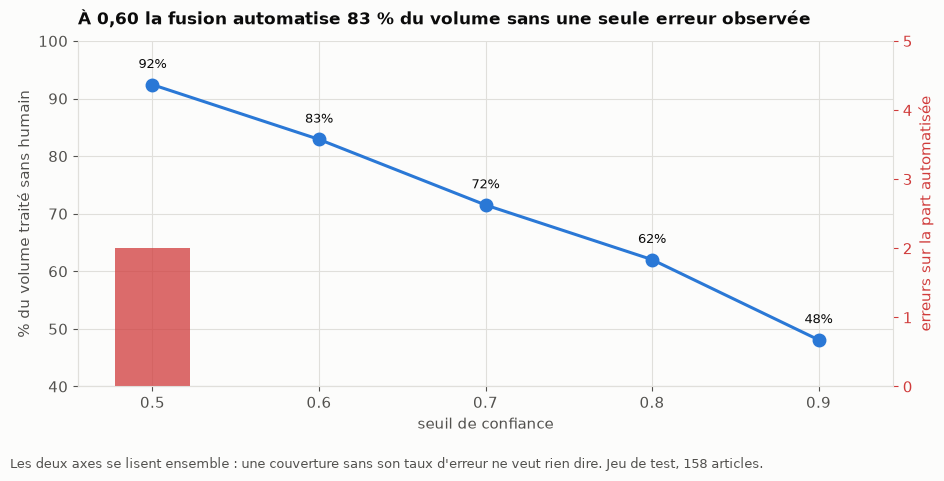

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(
    t_fusion["Seuil"],
    t_fusion["Couverture"] * 100,
    "-o",
    color=BLEU,
    lw=2.2,
    ms=9,
    label="couverture automatique",
    zorder=3,
)
ax.set_xlabel("seuil de confiance")
ax.set_ylabel("% du volume traité sans humain")
ax.set_ylim(40, 100)
ax.grid(color=GRILLE, lw=0.8, zorder=0)

ax2 = ax.twinx()
ax2.bar(
    t_fusion["Seuil"],
    t_fusion["Erreurs"],
    width=0.045,
    color=ROUGE,
    alpha=0.75,
    label="erreurs",
    zorder=2,
)
ax2.set_ylabel("erreurs sur la part automatisée", color=ROUGE)
ax2.tick_params(axis="y", colors=ROUGE)
ax2.set_ylim(0, 5)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(GRILLE)

for _, r in t_fusion.iterrows():
    ax.annotate(
        f"{r['Couverture']:.0%}",
        (r["Seuil"], r["Couverture"] * 100),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9.5,
    )
ax.set_title(
    "À 0,60 la fusion automatise 83 % du volume sans une seule erreur observée",
    fontsize=12.5,
    fontweight="bold",
    loc="left",
    pad=12,
)
fig.text(
    0.01,
    0.01,
    "Les deux axes se lisent ensemble : une couverture sans son taux d'erreur "
    "ne veut rien dire. Jeu de test, 158 articles.",
    fontsize=9,
    color=ENCRE_2,
)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

> **Seuil recommandé : 0,60.** La fusion atteint zéro erreur observée dès ce seuil, en couvrant
> 83 % du volume. Le modèle texte seul doit monter à 0,80 pour en faire autant, et ne couvre alors
> que 68 %. **L'image achète 15 points de couverture à qualité égale.**

**Une précaution de formulation.** On écrit « aucune erreur sur les 131 articles concernés », jamais
« 100 % de précision ». Sur cet effectif, un taux nul est un intervalle de confiance, pas une
garantie. Un évaluateur attentif fera la différence.

## 4 · Le cas concret

Un article que le texte seul classe mal, et que l'image rattrape.

In [9]:
from PIL import Image

from src.images import image_path

# On repère un article où texte et fusion divergent, et où la fusion a raison.
mlp_txt = MLPClassifier(
    hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True, random_state=SEED
).fit(X_tr, y_tr)
p_txt = mlp_txt.predict_proba(X_te)

pred_txt = np.array([CATEGORIES[i] for i in p_txt.argmax(1)])
pred_fus = np.array([CATEGORIES[i] for i in proba.argmax(1)])
vrai_a = np.array(vrai)
candidats = np.where((pred_txt != vrai_a) & (pred_fus == vrai_a))[0]
print(f"{len(candidats)} article(s) rattrapé(s) par l'image\n")

k = int(candidats[0])
ligne = test.iloc[k]
print(f"catégorie réelle : {ligne[LABEL_COL]}")
print(f"texte seul       : {pred_txt[k]:30s} confiance {p_txt[k].max():.1%}   ✗")
print(f"texte + image    : {pred_fus[k]:30s} confiance {proba[k].max():.1%}   ✓")
print(f"\n« {ligne[TEXT_COL][:200]}… »")

7 article(s) rattrapé(s) par l'image

catégorie réelle : Baby Care
texte seul       : Home Furnishing                confiance 39.2%   ✗
texte + image    : Baby Care                      confiance 74.9%   ✓

« Buy My NewBorn Solid Single Wrapper Assorted Muti Colors at Rs. 550 at Flipkart.com. Only Genuine Products. Free Shipping. Cash On Delivery!… »


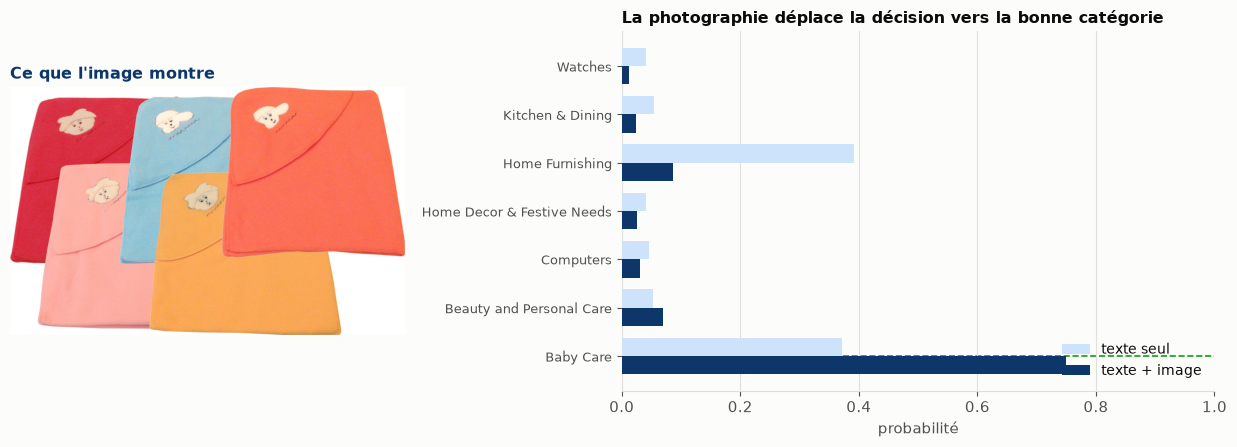

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1, 1.5]})
a1.imshow(Image.open(image_path(ligne["uniq_id"])).convert("RGB"))
a1.axis("off")
a1.set_title(
    "Ce que l'image montre", fontsize=11.5, fontweight="bold", color=BLEU_FONCE, loc="left"
)

y = np.arange(len(CATEGORIES))
h = 0.38
a2.barh(y + h / 2, p_txt[k], h, label="texte seul", color=BLEU_CLAIR, zorder=3)
a2.barh(y - h / 2, proba[k], h, label="texte + image", color=BLEU_FONCE, zorder=3)
a2.set_yticks(y)
a2.set_yticklabels(CATEGORIES, fontsize=9.5)
a2.set_xlabel("probabilité")
a2.set_xlim(0, 1)
a2.grid(axis="x", color=GRILLE, lw=0.8, zorder=0)
a2.legend(frameon=False, fontsize=10, loc="lower right")
a2.axhline(CATEGORIES.index(ligne[LABEL_COL]), color=VERT, lw=1.2, ls="--", zorder=1)
a2.set_title(
    "La photographie déplace la décision vers la bonne catégorie",
    fontsize=11.5,
    fontweight="bold",
    loc="left",
)
plt.tight_layout()
plt.show()

La description parle de matière et de dimensions — les mêmes mots qu'un ustensile de cuisine.
La photographie, elle, ne laisse aucun doute. C'est exactement le mécanisme que la F1 par classe
mesurait de façon agrégée.

## Ce qui sort de ce notebook

| | |
|---|---|
| Modèle retenu | Fusion texte + image — F1 macro 0,974 |
| Le gain qui compte | classe la plus faible 0,870 → **0,955** |
| Coût | 36 ms par article, 365 Mo — sous le budget de 200 ms |
| Seuil recommandé | **0,60** : 83 % du volume, aucune erreur observée |
| Repli | le modèle texte, quand aucune photographie n'est disponible |

→ Notebook suivant : **06 · Comparaison**, pour mettre les six approches face à face.